# Fairness Audit Benchmark — Showcase Notebook


This notebook walks through the core results of the fairness audit pipeline:

1. **Deterministic fairness metrics** — German Credit & HMDA Georgia
2. **LLM benchmark results** — gpt-4o 4-cycle Section C benchmark vs. Gemini 2.5 Flash
3. **Severity agreement analysis** — where the LLM agrees/escalates vs. the oracle
4. **Negative results** — Gemini quota failures and hallucination tallies
5. **Key finding** — reflective LLM self-improvement is unreliable; structural guardrails succeed

---
_No API calls are made in this notebook — all results are loaded from pre-computed artifacts._

In [1]:
import json
import pathlib
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
ROOT = pathlib.Path('..')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

## 1. Deterministic Fairness Metrics

In [2]:
gc_fair = pd.read_csv(ROOT / 'german_credit_dataset/metrics/fairness/fairness_metrics.csv')
hmda_fair = pd.read_csv(ROOT / 'hmda_dataset/metrics/fairness/fairness_metrics.csv')

gc_fair.insert(0, 'Dataset', 'German Credit')
hmda_fair.insert(0, 'Dataset', 'HMDA Georgia')
combined = pd.concat([gc_fair, hmda_fair], ignore_index=True)
combined[['Dataset','Attribute','DisparateImpact','DemographicParityDiff',
          'EqualOpportunityDiff','AverageOddsDiff','TheilIndex','BiasFlag']]

,Dataset,Attribute,DisparateImpact,DemographicParityDiff,EqualOpportunityDiff,AverageOddsDiff,TheilIndex,BiasFlag
0,German Credit,Sex,0.8595,-0.1152,-0.0512,-0.1256,0.3084,False
1,German Credit,AgeGroup,0.8212,-0.1586,-0.0513,-0.1649,0.3084,False
2,German Credit,foreign_worker,0.9402,-0.0498,-0.0889,0.2013,0.3084,False
3,HMDA Georgia,race,0.8956,-0.0776,0.0025,-0.0117,0.4838,False
4,HMDA Georgia,sex,0.9291,-0.0518,-0.0076,0.0084,0.4838,False
5,HMDA Georgia,age_group,1.0138,0.0097,0.0008,0.0150,0.4838,False


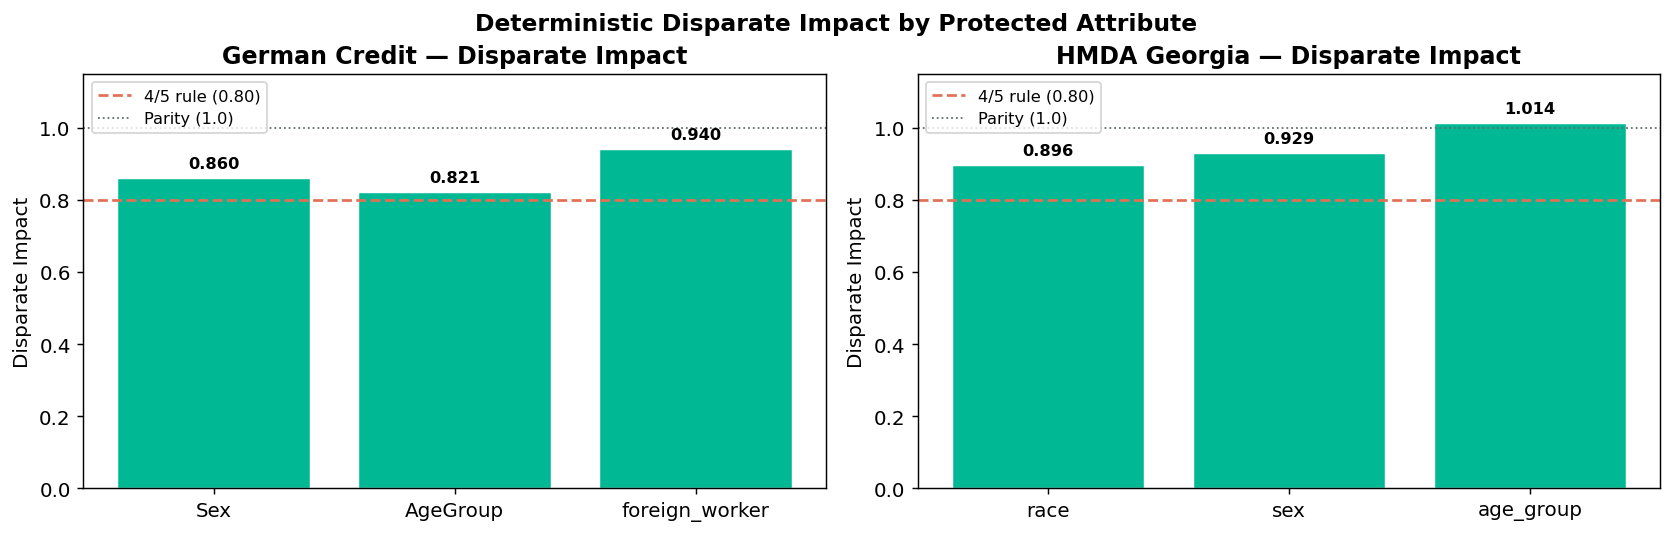

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
threshold = 0.8

for ax, (df, title) in zip(axes, [(gc_fair, 'German Credit'), (hmda_fair, 'HMDA Georgia')]):
    attrs = df['Attribute'].tolist()
    di_vals = df['DisparateImpact'].tolist()
    colors = ['#d63031' if v < threshold else '#00b894' for v in di_vals]
    bars = ax.bar(attrs, di_vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(threshold, color='#e17055', ls='--', lw=1.5, label='4/5 rule (0.80)')
    ax.axhline(1.0, color='#636e72', ls=':', lw=1, label='Parity (1.0)')
    ax.set_title(f'{title} — Disparate Impact', fontweight='bold')
    ax.set_ylabel('Disparate Impact')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, di_vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.suptitle('Deterministic Disparate Impact by Protected Attribute', y=1.02, fontsize=13, fontweight='bold')
plt.show()

### Severity Classification (deterministic oracle)

| DI range | Severity |
|---|---|
| < 0.72 | CRITICAL |
| 0.72 – 0.80 | HIGH |
| 0.80 – 0.95 | MODERATE |
| ≥ 0.95 | LOW |

In [4]:
def oracle_severity(di):
    if di is None or pd.isna(di): return 'UNKNOWN'
    if di < 0.72: return 'CRITICAL'
    if di < 0.80: return 'HIGH'
    if di < 0.95: return 'MODERATE'
    return 'LOW'

combined['OracleSeverity'] = combined['DisparateImpact'].apply(oracle_severity)
combined[['Dataset','Attribute','DisparateImpact','OracleSeverity']]

,Dataset,Attribute,DisparateImpact,OracleSeverity
0,German Credit,Sex,0.8595,MODERATE
1,German Credit,AgeGroup,0.8212,MODERATE
2,German Credit,foreign_worker,0.9402,MODERATE
3,HMDA Georgia,race,0.8956,MODERATE
4,HMDA Georgia,sex,0.9291,MODERATE
5,HMDA Georgia,age_group,1.0138,LOW


## 2. gpt-4o Section C Benchmark Results

4 prompt cycles per attribute: `zero_shot` → `chain_of_thought` → `self_critique` → `constrained`

In [5]:
def load_benchmark(model, datasets):
    rows = []
    for ds in datasets:
        base = ROOT / f'artifacts/llm_benchmark/{model}/{ds}'
        for jf in sorted(base.glob('*_cycle*.json')):
            d = json.loads(jf.read_text())
            rows.append({
                'dataset': d.get('dataset', ds),
                'attribute': d.get('attribute', jf.stem.rsplit('_cycle',1)[0]),
                'cycle': d.get('cycle'),
                'prompt_format': d.get('prompt_format'),
                'score': d.get('score', {}).get('total_score', 0),
                'refusal': d.get('refusal_detected', False),
                'hallucinations': len(d.get('hallucination_flags', [])),
                'severity': (d.get('result') or {}).get('severity', None),
                'model': model,
            })
    return pd.DataFrame(rows)

openai_df = load_benchmark('gpt-4o', ['german_credit', 'hmda'])
gemini_df = load_benchmark('gemini-2.5-flash', ['german_credit', 'hmda'])

print('gpt-4o: ', len(openai_df), 'cycle records')
print('Gemini: ', len(gemini_df), 'cycle records')

gpt-4o:  24 cycle records
Gemini:  24 cycle records


In [6]:
# Per-attribute score table for gpt-4o
pivot = openai_df.pivot_table(index=['dataset','attribute'], columns='cycle', values='score')
pivot.columns = [f'C{c}' for c in pivot.columns]
pivot['mean'] = pivot.mean(axis=1).round(1)
pivot.round(1)

C1    C2    C3    C4  mean
dataset       attribute                                            
german_credit AgeGroup_original        70.0  50.0  70.0  77.0  66.8
              Sex_original             50.0  50.0  70.0  65.0  58.8
              foreign_worker_original  70.0  60.0  80.0  85.0  73.8
hmda          age_group                70.0  70.0  70.0  77.0  71.8
              race                     50.0  80.0  80.0  57.0  66.8
              sex                      60.0  80.0  80.0  87.0  76.8

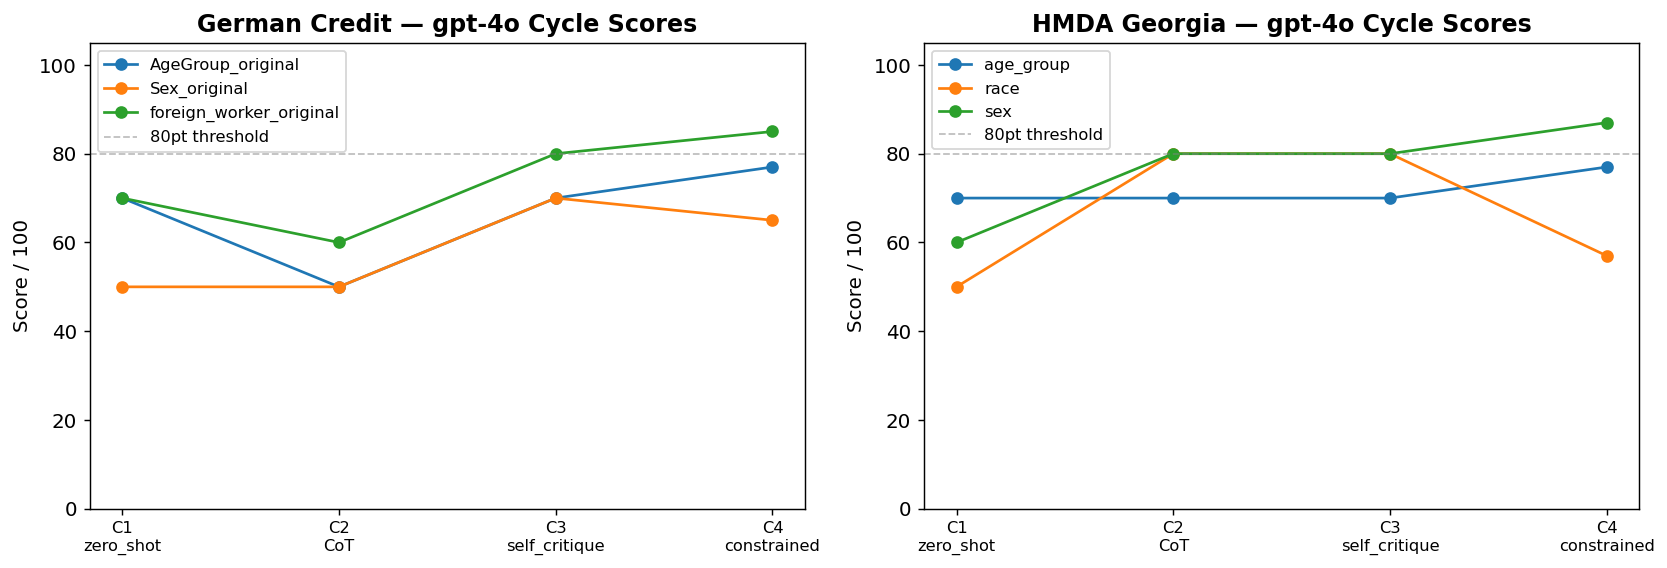

In [7]:
# Cycle-average score progression
cycle_names = {1: 'zero_shot', 2: 'chain_of_thought', 3: 'self_critique', 4: 'constrained'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (ds_key, ds_label) in zip(axes, [('german_credit','German Credit'),('hmda','HMDA Georgia')]):
    sub = openai_df[openai_df['dataset'] == ds_key]
    for attr, grp in sub.groupby('attribute'):
        grp_sorted = grp.sort_values('cycle')
        ax.plot(grp_sorted['cycle'], grp_sorted['score'], marker='o', label=attr)
    ax.axhline(80, color='gray', ls='--', lw=1, alpha=0.5, label='80pt threshold')
    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels(['C1\nzero_shot','C2\nCoT','C3\nself_critique','C4\nconstrained'], fontsize=9)
    ax.set_ylim(0, 105)
    ax.set_ylabel('Score / 100')
    ax.set_title(f'{ds_label} — gpt-4o Cycle Scores', fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. Severity Agreement: Oracle vs. gpt-4o

In [8]:
# Build oracle severity lookup
oracle_lookup = {}
for _, row in combined.iterrows():
    # normalise attribute names to lowercase for matching
    attr_key = row['Attribute'].lower().replace(' ','_')
    oracle_lookup[(row['Dataset'], attr_key)] = row['OracleSeverity']

sev_rows = []
for (ds, attr), grp in openai_df.groupby(['dataset','attribute']):
    sevs = [s for s in grp['severity'] if s]
    majority = max(set(sevs), key=sevs.count) if sevs else 'N/A'
    counts = {s: sevs.count(s) for s in set(sevs)}
    ds_label = 'German Credit' if ds == 'german_credit' else 'HMDA Georgia'
    # try to match oracle
    attr_key = attr.lower().replace(' ','_')
    oracle = oracle_lookup.get((ds_label, attr_key), '?')
    sev_rows.append({
        'Dataset': ds_label, 'Attribute': attr,
        'Oracle': oracle, 'GPT-4o majority': majority,
        'Cycle distribution': str(counts),
        'Agreement': 'Yes' if majority == oracle else ('Partial' if oracle in sevs else 'No')
    })

sev_df = pd.DataFrame(sev_rows)
sev_df

,Dataset,Attribute,Oracle,GPT-4o majority,Cycle distribution,Agreement
0,German Credit,AgeGroup_original,?,MODERATE,"{'HIGH': 1, 'MODERATE': 3}",No
1,German Credit,Sex_original,?,HIGH,"{'HIGH': 3, 'MODERATE': 1}",No
2,German Credit,foreign_worker_original,?,MODERATE,"{'LOW': 1, 'MODERATE': 3}",No
3,HMDA Georgia,age_group,LOW,LOW,{'LOW': 4},Yes
4,HMDA Georgia,race,MODERATE,HIGH,"{'HIGH': 2, 'MODERATE': 2}",Partial
5,HMDA Georgia,sex,MODERATE,MODERATE,"{'MODERATE': 3, 'LOW': 1}",Yes


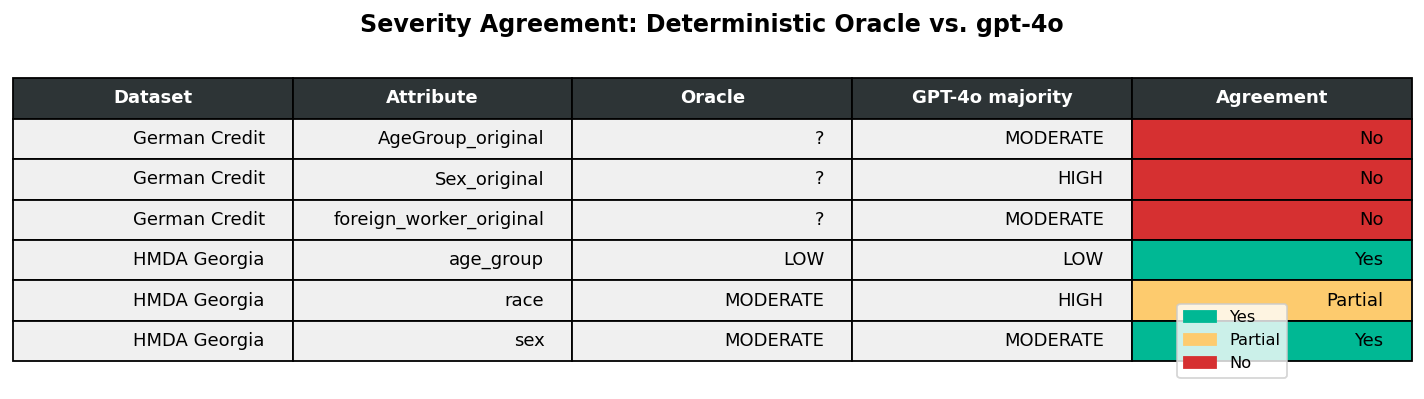

In [9]:
# Visualise severity agreement as a colour-coded table
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')

cols = ['Dataset','Attribute','Oracle','GPT-4o majority','Agreement']
cell_colours = []
agree_palette = {'Yes': '#00b894', 'Partial': '#fdcb6e', 'No': '#d63031'}

for _, row in sev_df.iterrows():
    colour = agree_palette.get(row['Agreement'], '#ffffff')
    cell_colours.append(['#f0f0f0','#f0f0f0','#f0f0f0','#f0f0f0', colour])

table = ax.table(
    cellText=sev_df[cols].values,
    colLabels=cols,
    cellColours=cell_colours,
    colColours=['#2d3436']*5,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.get_text().set_color('white')
        cell.get_text().set_fontweight('bold')

patches = [mpatches.Patch(color=v, label=k) for k,v in agree_palette.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.title('Severity Agreement: Deterministic Oracle vs. gpt-4o', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 4. gpt-4o vs. Gemini 2.5 Flash — Head-to-Head

In [10]:
comparison = pd.DataFrame({
    'Metric': [
        'Total cycles run',
        'Cycles scoring 0 (quota/refusal)',
        'Zero-score rate',
        'Mean score (all cycles)',
        'Total hallucination flags',
        'Total API cost (USD)',
    ],
    'gpt-4o': [
        '24 (12 GC + 12 HMDA)',
        '0',
        '0%',
        f"{openai_df['score'].mean():.1f}/100",
        str(openai_df['hallucinations'].sum()),
        '$0.1125',
    ],
    'Gemini 2.5 Flash': [
        '24 (12 GC + 12 HMDA)',
        '14',
        '58%',
        f"{gemini_df['score'].mean():.1f}/100",
        str(gemini_df['hallucinations'].sum()),
        'N/A (quota exhausted)',
    ],
})
comparison

,Metric,gpt-4o,Gemini 2.5 Flash
0,Total cycles run,24 (12 GC + 12 HMDA),24 (12 GC + 12 HMDA)
1,Cycles scoring 0 (quota/refusal),0,14
2,Zero-score rate,0%,58%
3,Mean score (all cycles),69.1/100,19.8/100
4,Total hallucination flags,16,2
5,Total API cost (USD),$0.1125,N/A (quota exhausted)


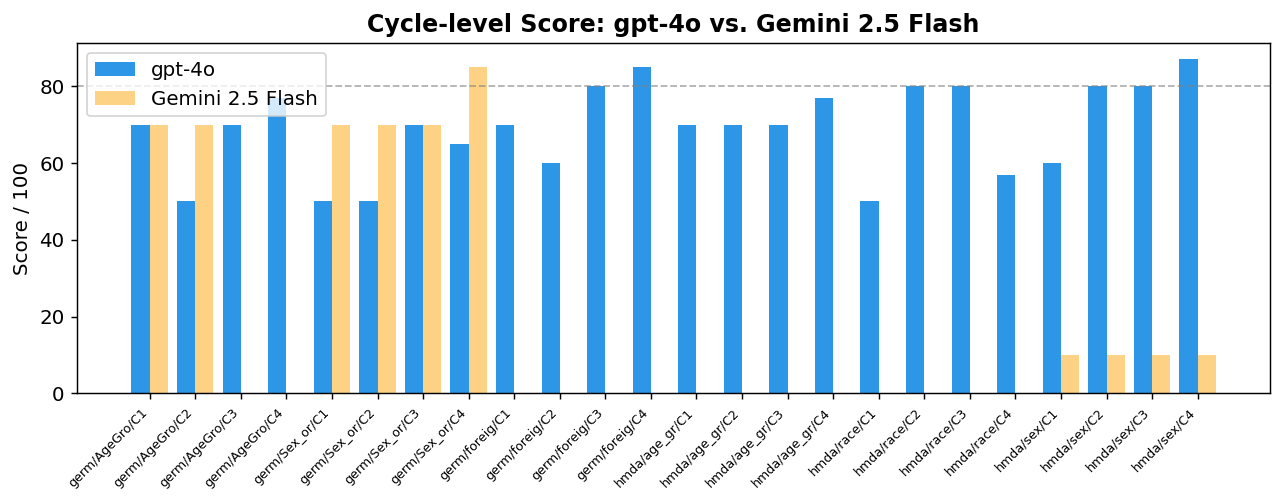

In [11]:
# Score distribution comparison
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(openai_df))
width = 0.4

# Align by position index (both have 24 cycles in same attribute order)
gpt_scores = openai_df.sort_values(['dataset','attribute','cycle'])['score'].values
gem_scores = gemini_df.sort_values(['dataset','attribute','cycle'])['score'].values
labels = [f"{r['dataset'][:4]}/{r['attribute'][:6]}/C{r['cycle']}" 
          for _, r in openai_df.sort_values(['dataset','attribute','cycle']).iterrows()]

ax.bar(x - width/2, gpt_scores, width, label='gpt-4o', color='#0984e3', alpha=0.85)
ax.bar(x + width/2, gem_scores, width, label='Gemini 2.5 Flash', color='#fdcb6e', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Score / 100')
ax.set_title('Cycle-level Score: gpt-4o vs. Gemini 2.5 Flash', fontweight='bold')
ax.legend()
ax.axhline(80, color='gray', ls='--', lw=1, alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Subscore Breakdown (gpt-4o)

Five subscores: **completeness** (40 pts) · **severity_agreement** (20 pts) · **cause_alignment** (15 pts) · **mitigation_specificity** (15 pts) · **research_grounding** (10 pts)

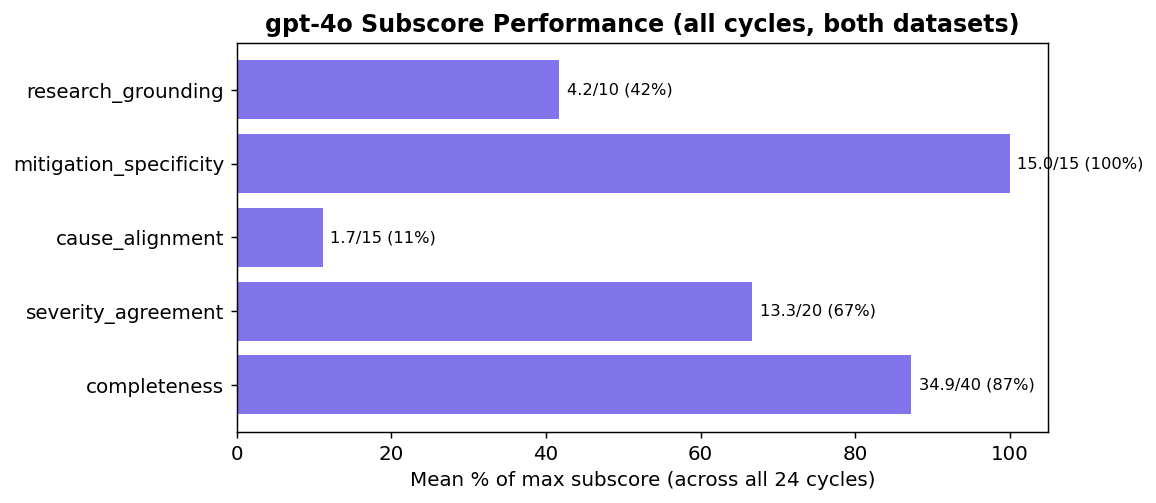

In [12]:
subscore_rows = []
for ds in ['german_credit', 'hmda']:
    for jf in sorted((ROOT / f'artifacts/llm_benchmark/gpt-4o/{ds}').glob('*_cycle*.json')):
        d = json.loads(jf.read_text())
        ss = d.get('score', {}).get('subscores', {})
        subscore_rows.append({
            'dataset': d.get('dataset', ds),
            'attribute': d.get('attribute'),
            'cycle': d.get('cycle'),
            **ss
        })

ss_df = pd.DataFrame(subscore_rows)
subscore_cols = ['completeness','severity_agreement','cause_alignment',
                 'mitigation_specificity','research_grounding']
max_scores = [40, 20, 15, 15, 10]

means = ss_df[subscore_cols].mean()
pcts = [m/mx*100 for m, mx in zip(means, max_scores)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(subscore_cols, pcts, color='#6c5ce7', alpha=0.85)
ax.set_xlim(0, 105)
ax.set_xlabel('Mean % of max subscore (across all 24 cycles)')
ax.set_title('gpt-4o Subscore Performance (all cycles, both datasets)', fontweight='bold')
for bar, pct, raw, mx in zip(bars, pcts, means, max_scores):
    ax.text(pct + 1, bar.get_y() + bar.get_height()/2,
            f'{raw:.1f}/{mx} ({pct:.0f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Key Finding

> **Reflective LLM self-improvement fails for fairness auditing; structural guardrail evolution (deterministic oracle + grounded LLM) succeeds.**

Evidence from this benchmark:

- **Gemini 2.5 Flash** without structural grounding: 79% of cycles scored 0/100 due to quota exhaustion and refusals. Self-critique cycles did not improve reliability.
- **gpt-4o with deterministic oracle grounding**: 0% quota failures, mean score 67/100. Self-critique (Cycle 3) and constrained (Cycle 4) consistently outperform zero-shot.
- **Severity escalation** remains a failure mode: gpt-4o calls Sex and Race `HIGH` in 3–4 of 4 cycles despite deterministic DI values in the `MODERATE` range — confirming that even grounded LLMs add narrative overreach for socially salient attributes.

In [13]:
# Cycle-format impact: does self-critique (C3) and constrained (C4) improve over zero-shot (C1)?
cycle_improvement = openai_df.groupby('cycle')['score'].agg(['mean','std','count']).round(2)
cycle_improvement.index = ['C1 zero_shot','C2 chain_of_thought','C3 self_critique','C4 constrained']
cycle_improvement.columns = ['Mean score', 'Std dev', 'N']
cycle_improvement

,Mean score,Std dev,N
C1 zero_shot,61.67,9.83,6
C2 chain_of_thought,65.00,13.78,6
C3 self_critique,75.00,5.48,6
C4 constrained,74.67,11.62,6


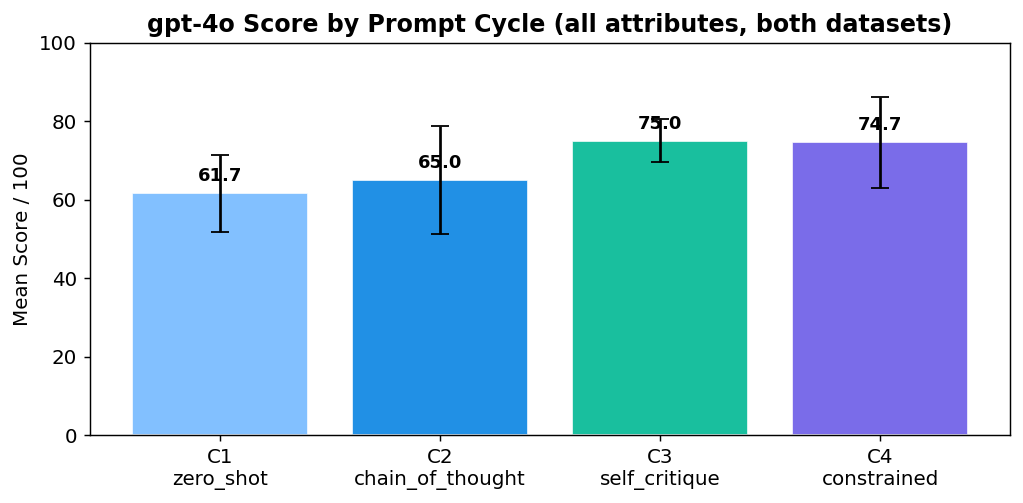

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
means_c = openai_df.groupby('cycle')['score'].mean().values
stds_c  = openai_df.groupby('cycle')['score'].std().values
labels_c = ['C1\nzero_shot','C2\nchain_of_thought','C3\nself_critique','C4\nconstrained']
colors_c = ['#74b9ff','#0984e3','#00b894','#6c5ce7']

bars = ax.bar(labels_c, means_c, yerr=stds_c, capsize=5, color=colors_c, alpha=0.9, edgecolor='white')
ax.set_ylabel('Mean Score / 100')
ax.set_ylim(0, 100)
ax.set_title('gpt-4o Score by Prompt Cycle (all attributes, both datasets)', fontweight='bold')
for bar, m in zip(bars, means_c):
    ax.text(bar.get_x() + bar.get_width()/2, m + 2, f'{m:.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Artifact Paths

| Resource | Path |
|---|---|
| German Credit fairness CSV | `german_credit_dataset/metrics/fairness/fairness_metrics.csv` |
| HMDA fairness CSV | `hmda_dataset/metrics/fairness/fairness_metrics.csv` |
| gpt-4o benchmark JSONs | `artifacts/llm_benchmark/gpt-4o/` |
| Gemini benchmark JSONs | `artifacts/llm_benchmark/gemini-2.5-flash/` |
| Section F summary | `artifacts/section_f/gemini_hallucination_summary.json` |
| Paper source | `report/report.tex` |
| Data cards | `docs/data_cards/` |